# Adapting xbatcher DL patterns for spatial gap-fill batching

Exploring what we can reuse from **Keenan Ganz's xbatcher deep-learning tutorial** (UW RSGAL) for our
spatial (40x56) gap-fill batching. For each feature we note whether it is in **mainline** xbatcher
(usable now), needs his **fork**, or is something we **reimplement**. Results are kept here for reference.

Runs on `xarray` + `dask` + `xbatcher` + `matplotlib`, no TF/torch needed just to explore the batching.

In [1]:
import os
import inspect
from time import perf_counter
import numpy as np
import pandas as pd
import xarray as xr
import dask
import xbatcher
from xbatcher import BatchGenerator
import matplotlib.pyplot as plt
import matplotlib.patches

## 1. Feature availability: mainline vs his fork

We verified on xbatcher 0.4.0 that the exciting features (`filter_fn`, `resample_fn`, `predict_on_array`)
are in Keenan's fork, not mainline, while `cache` and the framework loaders are in mainline. This cell
re-checks it live so the record matches whatever version is installed here.

In [2]:
print("xbatcher:", xbatcher.__version__)
params = list(inspect.signature(BatchGenerator).parameters)
print("BatchGenerator params:", params)
print("  filter_fn  (%-ocean patch filter)  in mainline?", "filter_fn" in params)
print("  resample_fn(weighted sampling)     in mainline?", "resample_fn" in params)
print("  cache      (read-once-reuse)       in mainline?", "cache" in params)
for mod, what in [("xbatcher.predict", "predict_on_array (stitching)"),
                  ("xbatcher.loaders.torch", "torch loader"),
                  ("xbatcher.loaders.keras", "keras/TF loader")]:
    try:
        __import__(mod); print(f"  {what:28s} present: {mod}")
    except ModuleNotFoundError:
        print(f"  {what:28s} MISSING (fork/newer version): {mod}")
    except ImportError:
        print(f"  {what:28s} present but needs its framework installed: {mod}")

xbatcher: 0.4.0
BatchGenerator params: ['ds', 'input_dims', 'input_overlap', 'batch_dims', 'concat_input_dims', 'preload_batch', 'cache', 'cache_preprocess']
  filter_fn  (%-ocean patch filter)  in mainline? False
  resample_fn(weighted sampling)     in mainline? False
  cache      (read-once-reuse)       in mainline? True
  predict_on_array (stitching) MISSING (fork/newer version): xbatcher.predict
  torch loader                 present but needs its framework installed: xbatcher.loaders.torch


2026-07-06 21:58:47.324379: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-06 21:58:47.339310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783375127.357762    2098 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783375127.364123    2098 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783375127.378421    2098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

  keras/TF loader              present: xbatcher.loaders.keras


## 2. Load the full grid

Full IO grid (no Arab Sea subset) so the 40x56 patches line up with the on-disk chunks. We load one day
into memory so the exploration below (patch viz, filtering, stitching) is fast and does not re-read.

In [3]:
raw = xr.open_zarr("/home/jovyan/shared-public/mindthegap/data/IO_rechunked.zarr", chunks={})
VAR = "CHL_cmes-level3"          # has NaN over land/gaps, so ocean-fraction is meaningful
print("full grid:", dict(raw[VAR].sizes))

day0 = raw[VAR].isel(time=0).load()   # one day, 2D, in memory for cheap exploration
print("one day:", dict(day0.sizes))

full grid: {'time': 9193, 'lat': 177, 'lon': 241}
one day: {'lat': 177, 'lon': 241}


## 3. Spatial patching (the task): 40x56 tiles

`input_dims` with `lat`/`lon` (and a small `time`) tiles the grid. This is the exact pattern from
Keenan's tutorial, plus a `time` axis. `DAY_BATCH` is just how many days are read per block; the sample
the model sees is still one day.

In [4]:
LAT_PATCH, LON_PATCH, DAY_BATCH = 40, 56, 1

# full space+time batcher (this is the real training batcher; a Dataset so it can carry many channels)
bg = BatchGenerator(raw[[VAR]],
                    input_dims={"time": DAY_BATCH, "lat": LAT_PATCH, "lon": LON_PATCH},
                    input_overlap={"time": 0, "lat": 0, "lon": 0})
print("num batches (space x time):", len(bg))
print("one batch dims:", dict(bg[0].sizes))

# spatial-only batcher on the single in-memory day, for the viz + filtering below
bg2d = BatchGenerator(day0, input_dims={"lat": LAT_PATCH, "lon": LON_PATCH},
                      input_overlap={"lat": 0, "lon": 0})
print("spatial tiles per day:", len(bg2d))

num batches (space x time): 147088
one batch dims: {'time': 1, 'lat': 40, 'lon': 56}
spatial tiles per day: 16


## 4. Visualize the tiling (adapted from Keenan's `draw_bgen_patches`)

His version reaches into an internal attribute; this one uses each patch's lat/lon coordinates instead,
so it is robust across xbatcher versions. Note the dropped partial edges (xbatcher never makes partial
patches), which is why the full grid, not the offset Arab Sea subset, gives clean alignment.

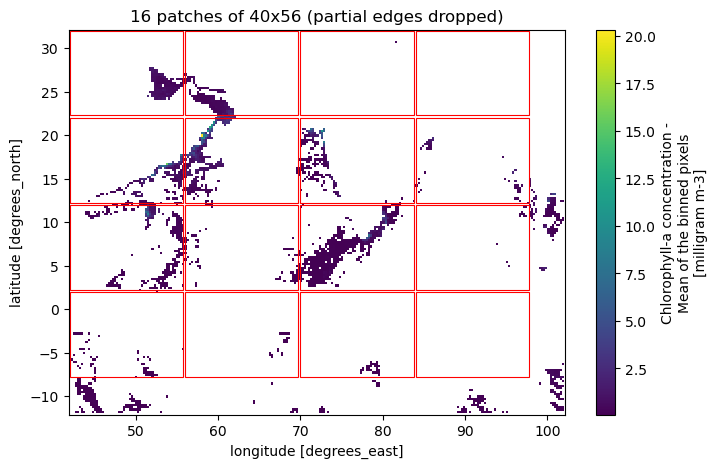

In [5]:
def draw_patches(bgen2d, background, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    background.plot.imshow(ax=ax, add_colorbar=True, cmap="viridis")
    for i in range(len(bgen2d)):
        p = bgen2d[i]
        lo0, lo1 = float(p.lon.min()), float(p.lon.max())
        la0, la1 = float(p.lat.min()), float(p.lat.max())
        ax.add_patch(matplotlib.patches.Rectangle((lo0, la0), lo1 - lo0, la1 - la0,
                                                  fill=False, edgecolor="red", lw=0.8))
    ax.set_title(title)
    plt.show()

draw_patches(bg2d, day0, f"{len(bg2d)} patches of {LAT_PATCH}x{LON_PATCH} (partial edges dropped)")

## 5. Percent-ocean filtering (reimplements `filter_fn`)

`filter_fn` is fork-only, and Keenan recommends **precomputing** valid patches over checking them in the
training loop anyway. So we score each patch by its fraction of finite (ocean-with-data) pixels and keep
a list of good indices. That `valid` list is what you would sample from during training, and it is the
concrete answer to the "% ocean" todo.

In [6]:
def ocean_frac(patch):
    return float(np.isfinite(patch.values).mean())

fracs = np.array([ocean_frac(bg2d[i]) for i in range(len(bg2d))])
THRESH = 0.5
valid = np.where(fracs >= THRESH)[0]
print(f"{len(valid)}/{len(bg2d)} patches are >= {THRESH:.0%} ocean-with-data")
print("ocean-fraction range across patches:", round(fracs.min(), 2), "to", round(fracs.max(), 2))
# `valid` is the precomputed index list; sample training patches from it instead of all patches

0/16 patches are >= 50% ocean-with-data
ocean-fraction range across patches: 0.0 to 0.21


## 6. Caching (mainline `cache` param, no fork needed)

xbatcher's built-in `cache` (a dict) stores computed batches, giving the read-once-reuse we hand-rolled
in the speed notebook, for free. On synthetic data we saw ~50x on re-access; check it here on the real
store.

In [7]:
bg_cache = BatchGenerator(raw[[VAR]],
                          input_dims={"time": DAY_BATCH, "lat": LAT_PATCH, "lon": LON_PATCH},
                          input_overlap={"time": 0, "lat": 0, "lon": 0},
                          cache={})
t = perf_counter(); _ = bg_cache[0]; first = perf_counter() - t
t = perf_counter(); _ = bg_cache[0]; second = perf_counter() - t
print(f"cache: first access {first:6.2f} s, second access {second * 1000:6.1f} ms")
print("re-access speedup:", round(first / max(second, 1e-9)), "x")

TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'> instead.

## 7. Stitching predictions back (reimplements `predict_on_array`)

`predict_on_array` is fork-only and torch-oriented. The manual version: make an empty full-grid array,
run each patch through the model, and place the output back by its coordinates. Here the "prediction" is
just the input patch as a placeholder; swap in `model.predict(...)` later. This is the "combine several
patches into one larger prediction" task, and it is a small amount of code once the tiling is set up.

In [ ]:
pred_day = xr.full_like(day0, np.nan)
for i in range(len(bg2d)):
    p = bg2d[i]
    pred_day.loc[dict(lat=p.lat, lon=p.lon)] = p.values   # placeholder: replace with model output
filled = int(np.isfinite(pred_day.values).sum())
print(f"stitched {len(bg2d)} patches into the full grid: {filled}/{pred_day.size} pixels filled")
draw_patches(bg2d, pred_day, "reassembled full-grid map (placeholder prediction)")

## Summary: what we can use

- **Mainline, use now:** `input_dims` spatial patching; the `cache` param for read-once-reuse (big
  re-access speedup); `loaders.keras` may replace our `make_tf_gen` (needs TF, check on the Hub).
- **Reimplement, no fork needed:** % ocean filtering -> precompute valid patch indices (section 5);
  stitching -> place patches back by coordinates (section 7). Keenan recommends precomputing anyway.
- **Fork-only (`ganzk`/xbatcher):** `filter_fn`, `resample_fn`, `predict_on_array`. Install the fork if
  we want them off the shelf instead of reimplementing.
- **Shuffling caveat (from his study):** patches are generated sequentially and shuffling strategy
  "drastically impacted performance." So per-tile caching must not become "train one tile to
  exhaustion." Cache a **pool** of tiles and shuffle across it.

Questions for Keenan (UW RSGAL): (1) how to balance per-chunk caching against shuffling for
out-of-memory `time=1` cloud data; (2) does `predict_on_array` work with a TF/Keras model; (3) is the
precompute-valid-patches approach the right one for banded-gap PACE data, and how to store/reuse the
index across runs.